In [26]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [27]:
# make random distances
n_nodes = 20
cross_costs = np.random.rand(n_nodes, n_nodes)
cross_costs = (cross_costs + cross_costs.T) / 2
for i in range(n_nodes): cross_costs[i,i] = 0

In [28]:
# order edges 
cross_costs_ordered = [(cross_costs[i,j], (i,j)) for i in range(n_nodes) for j in range(n_nodes)]
cross_costs_ordered = sorted(
    cross_costs_ordered,
    key=lambda x: x[0]
)
cross_costs = torch.tensor(cross_costs)

In [29]:
H = torch.tensor([1 for i in range(n_nodes)])
B = torch.tensor([10 for i in range(n_nodes)])

In [30]:
def fulfilment_loss(q, d):
    
    aa = torch.zeros(q.shape[0], n_nodes, n_nodes)
    # print(aa.shape, q.shape, d.shape)

    for i in range(n_nodes):
        for j in range(n_nodes):
            curq = q[:,i]
            curd = d[:,j]
            for edge in cross_costs_ordered:
                # print(edge)
                l,k = edge[1]
                if l == i:
                    curq = curq - aa[:,l,k]
                if k == j:   
                    curd = curd - aa[:,l,k]
            aa[:,i,j] = torch.minimum(curq, curd)

    # calculate cost 
    # holding_cost = sum(H[i] * (q[:,i] - sum(aa[:,i,j] for j in range(n_nodes))) for i in range(n_nodes))
    # backorder_cost = sum(B[i] * (d[:,i] - sum(aa[:,j,i] for j in range(n_nodes))) for i in range(n_nodes))
    # edge_cost = sum(aa[:,i,j] * cross_costs[i,j] for i in range(n_nodes) for k in range(n_nodes))
    # return holding_cost + backorder_cost + edge_cost 

    holding_cost = torch.sum(torch.sum(H * (q - torch.sum(aa, dim=2)), dim = 1), dim = 0)
    backorder_cost = torch.sum(torch.sum(B * (d - torch.sum(aa, dim=1)), dim = 1), dim = 0)
    edge_cost = torch.sum(aa * cross_costs)
    return holding_cost + backorder_cost + edge_cost 

In [31]:
def eval_forecast_model(X_train, model, D):    
    q = model(X_train) 
    return fulfilment_loss(q, D) 

In [32]:
n_data = 1000
n_features = 10

data_model = nn.Sequential(
  nn.Linear(n_features, n_nodes),
  nn.ReLU(),
)

def make_data(n_data):
    X2 = 2 * torch.randn(n_data, n_features) + 0.1
    X1 = torch.randn(n_data, n_features) - 0.2
    mu = torch.rand(n_data)
    mu = mu.view(-1,1).repeat(1,n_features)
    X = (X1 + X2 * mu)
    
    y = data_model(X) 
    y = 0.1 + F.relu(y + 0.1 * torch.randn(y.shape))
    return y**2, X

Y, X_train = make_data(n_data)
Y_test, X_test = make_data(1000)


In [33]:
class Forecast(nn.Module):
    def __init__(self, n_features, n_demands):
        super(Forecast, self).__init__()
    
        self.forecast = nn.Linear(n_features, n_nodes)
        # self.linear = nn.Linear(n_features, 100)
        # self.forecast = nn.Linear(100, 2)

    def forward(self, x): 
        # f = F.relu(self.linear(x))
        # return F.relu(self.forecast(f)) 
        
        f = F.relu(self.forecast(x))
        return F.relu(f + 0.1) 
#         return newsvendor.get_cost_from_prob(f)

In [41]:
# two - stage 

YY = Y.clone()

two_stage_forecast = Forecast(n_features, n_nodes)

criterion = nn.MSELoss()
optimizer_twostage = optim.Adam(two_stage_forecast.parameters(), lr=0.0001)

all_errs = []
mses = []
batch_size = 10
for epoch in range(1000):  # loop over the dataset multiple times
    for i in range(0, YY.size()[0], batch_size):
        c = torch.tensor(YY[i:i+batch_size:]).float()
        input = torch.tensor(X_train[i:i+batch_size,:]).float()

        optimizer_twostage.zero_grad()

        f = two_stage_forecast(input)
        
        # print(f)
        # print(c)
        mse = criterion(f, c) 

        mse.backward()
        optimizer_twostage.step()
        
        mses = np.append(mses, mse.detach().numpy())
#     if epoch % 50 == : 
#         errs_two_stage = eval_forecast_model(X_test, two_stage_forecast, test_targets)
#         all_errs.append(np.mean(errs_two_stage))
#         print("Error: ", np.mean(errs_two_stage))
    # print("MSE: ", np.mean(mses))
    if epoch % 10 == 0:
        test_errs = eval_forecast_model(X_test, two_stage_forecast, Y_test) / len(X_test)
        train_errs = eval_forecast_model(X_train, two_stage_forecast, Y) / len(X_train)
        print("true error: ", test_errs.item(), train_errs.item())

C:\Users\rares\AppData\Local\Temp/ipykernel_4516/539088665.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c = torch.tensor(YY[i:i+batch_size:]).float()
C:\Users\rares\AppData\Local\Temp/ipykernel_4516/539088665.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(X_train[i:i+batch_size,:]).float()


true error:  28.908266384831723 28.51058142800923
true error:  31.29831219158846 30.792353323105896
true error:  31.377280438271427 30.87291783551296
true error:  29.655281983788534 29.156114614728946
true error:  26.813663821101485 26.07650592127838
true error:  23.740544340817785 22.693875841357094
true error:  20.96212654610031 19.624470118339975
true error:  18.692338787338123 17.122467527045135
true error:  16.96439061192218 15.22547653460063
true error:  15.65132666003293 13.783607788019268
true error:  14.65235450792329 12.741817130496777
true error:  13.873721776748477 11.932202526871395
true error:  13.22975525620806 11.29133873675966
true error:  12.693114211284994 10.782884117628914
true error:  12.23238372990016 10.36366426798449
true error:  11.827169334218363 10.008622669090851
true error:  11.465368982226657 9.692034113250145
true error:  11.134424781106476 9.40689897617156
true error:  10.833053199294662 9.15147419485684
true error:  10.556263734748695 8.915272852260998

In [42]:
import copy 

forecast = copy.deepcopy(two_stage_forecast)

best_error = 100000
optimizer_task = optim.Adam(forecast.parameters(), lr=0.00005)
criterion = nn.MSELoss()

all_errs = []
all_test_errs = []
batch_size = 50
for epoch in range(24):  # loop over the dataset multiple times
    for i in range(0, YY.size()[0], batch_size):
        d = torch.tensor(YY[i:i+batch_size:]).float()
        input = torch.tensor(X_train[i:i+batch_size,:]).float()

        optimizer_twostage.zero_grad()

        f = forecast(input)

        error = fulfilment_loss(f, d) / len(d)
        mse = criterion(f, d)
        error += mse * 10

        error.backward()
        optimizer_task.step()

        all_errs.append(error.detach().numpy())
#     if epoch % 50 == : 
#         errs_two_stage = eval_forecast_model(X_test, two_stage_forecast, test_targets)
#         all_errs.append(np.mean(errs_two_stage))
#         print("Error: ", np.mean(errs_two_stage))
    if epoch % 1 == 0:
        print("epoch:", epoch)
        print("Cost: ", np.mean(all_errs))
        test_errs = eval_forecast_model(X_test, forecast, Y_test) / len(X_test)
        train_errs = eval_forecast_model(X_train, forecast, Y) / len(X_train)
        print("true cost: ", test_errs.item(), train_errs.item())
        all_test_errs.append(test_errs.item())

        if test_errs < best_error: 
            best_error = test_errs
# torch.save(forecast.state_dict(), 'best-model-parameters.pt') # official recommended
# forecast.load_state_dict(torch.load('./best-model-parameters.pt'))

C:\Users\rares\AppData\Local\Temp/ipykernel_4516/2167296096.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d = torch.tensor(YY[i:i+batch_size:]).float()
C:\Users\rares\AppData\Local\Temp/ipykernel_4516/2167296096.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(X_train[i:i+batch_size,:]).float()


epoch: 0
Cost:  5.755146029668374
true cost:  5.679144866566443 5.038228506799695
epoch: 1
Cost:  5.718312746858734
true cost:  5.585876431062512 4.959646648146067
epoch: 2
Cost:  5.679004520495416
true cost:  5.489859909364663 4.8766090452461
epoch: 3
Cost:  5.638939718270317
true cost:  5.395989684496953 4.797154925583037
epoch: 4
Cost:  5.60014353647761
true cost:  5.305145500828735 4.72425816472851
epoch: 5
Cost:  5.5629585208264585
true cost:  5.220221924789063 4.656743706803846
epoch: 6
Cost:  5.527522691548152
true cost:  5.140177323330198 4.5940876669184725
epoch: 7
Cost:  5.4939736879156875
true cost:  5.066579036036479 4.538352064342272
epoch: 8
Cost:  5.462708472831298
true cost:  4.9958112112805475 4.493192964764504
epoch: 9
Cost:  5.433768076973285
true cost:  4.931516975449161 4.451754497874442
epoch: 10
Cost:  5.406825678026794
true cost:  4.8760236069985305 4.415172980337517
epoch: 11
Cost:  5.381754324854737
true cost:  4.827814261325404 4.380873486218033
epoch: 12
Cos

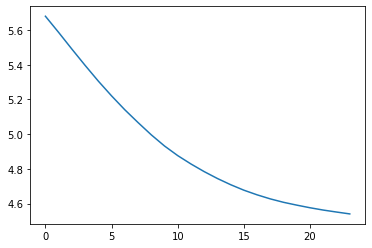

In [50]:
import matplotlib.pyplot as plt 

plt.plot(range(len(all_test_errs)), all_test_errs)

In [52]:
min(all_test_errs)

4.540164019428793

In [53]:
# two-stage with distribution and saa

def generate_samples(n_samples, means, rho): 
    noises = torch.rand(n_samples, means.shape[0]) * rho
    return (torch.tensor(means) * ( 1 + noises)).detach().numpy()

def saa(demands, holding, backorder, edges, q = None, test = False): 
    K = demands.shape[0]
    N = demands.shape[1] 

    with gp.Env(empty=True) as env:
        env.setParam('OutputFlag', 0)
        env.start()
        with gp.Model(env=env) as solver:
            a_ = [(k,i,j) for k in range(K) for i in range(N) for j in range(N)]
            q_ = [i for i in range(N)]
            a = solver.addVars(a_, lb = 0, name='a')
            if test is False: 
                q = solver.addVars(q_, lb = 0, name='q')
            m = solver.addVar(lb = 0)

            for k in range(K): 
                for i in range(N): 
                    solver.addConstr(sum(a[k,i,j] for j in range(N)) <= q[i])
                    solver.addConstr(sum(a[k,j,i] for j in range(N)) <= demands[k,i])
            solver.setObjective(
                    sum( # K
                        holding[0] * sum(q[i] - sum(a[k,i,j] for j in range(N)) for i in range(N)) +
                        backorder[0] * sum(demands[k,i] - sum(a[k,j,i] for j in range(N)) for i in range(N)) +
                        sum(edges[i][j] * a[k,i,j] for i in range(N) for j in range(N))
                        for k in range(K)) 
                    , GRB.MINIMIZE)
                
            solver.optimize()
            qq = []
            for v in solver.getVars():
                # print(v.VarName)
                if 'q' in v.VarName:
                    qq.append(v.X)
                # if 'a' in v.VarName: 
                #     print(v.VarName, v.X)
            return torch.tensor(qq).unsqueeze(0), solver.getObjective().getValue() / N

In [54]:
# evaluate end-to-end
all_costs = [] 
all_decisions = []

saa_rho = 0.1
saa_n_samples =     

t = 0
for x,d in zip(X_test, Y_test): 
    if t > 300: break
    t += 1
    
    pred = forecast(x)
    samples = generate_samples(saa_n_samples, pred, saa_rho)
    # print(pred, pred.shape)
    # print('the demands', samples, pred)
    decision, _ = saa(samples, H, B, cross_costs, test=False) 
    _, cost = saa(d.unsqueeze(0).detach().numpy(), H, B, cross_costs, decision[0].detach().numpy(), test=True)
    # cost = (decision, d.unsqueeze(0), H, B, C)
    # print('prediction', pred)
    # print(obj, cost)
    # print(pred, d)
    all_costs.append(cost)
    print(t, " ", np.mean(all_costs))
    all_decisions.append(decision[0].numpy())
all_decisions = np.array(all_decisions)
all_decisions = torch.tensor(all_decisions)

C:\Users\rares\AppData\Local\Temp/ipykernel_4516/186154808.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (torch.tensor(means) * ( 1 + noises)).detach().numpy()


1   0.06296147706168483
2   0.08743208835631172
3   0.11860172631040167
4   0.10823703708051528
5   0.1223488403883634
6   0.13024272081698615
7   0.12904207392257946
8   0.13506659439337998
9   0.14264642087897245
10   0.14425154148874153
11   0.1411544653689779
12   0.14548945824251971
13   0.15052340884860405
14   0.14412183954882174
15   0.13731708232609238
16   0.13477922122332509
17   0.13068946301755088
18   0.13221276396446022
19   0.1319722148495893
20   0.13437676542805543
21   0.1333063317776227
22   0.13945704430093733
23   0.140633204667684
24   0.13802004351787397
25   0.13742653147514983
26   0.13941315914147567
27   0.13813722065341116
28   0.13623504183096172
29   0.1325039729106397
30   0.12916603963756587
31   0.12641500573298822
32   0.12335486448603493
33   0.12287238485322222
34   0.12286714073705755
35   0.12224948624061466
36   0.12082034541019523
37   0.119680928408038
38   0.1173009103197555
39   0.12050167792805201
40   0.12023876648702461
41   0.118117279458

In [55]:
print(np.quantile(all_costs, 0.95))

0.2559421928280964


In [61]:
# evaluate two-stage 

saa_rho = 0.1
saa_n_samples = 100
all_costs_2 = [] 
all_decisions_2 = []
t = 0
for x,d in zip(X_test, Y_test): 
    if t >= 300: break 
    t+= 1
    pred = two_stage_forecast(x)
    samples = generate_samples(saa_n_samples, pred, saa_rho)
    # print('the demands', samples, pred)
    decision, _ = saa(samples, H, B, cross_costs)
    # print(decision)
    _, cost = saa(d.unsqueeze(0).detach().numpy(), H, B, cross_costs, decision[0].detach().numpy(), True)
    # cost = (decision, d.unsqueeze(0), H, B, C)
    # print('prediction', pred)
    # print(obj, cost)
    all_costs_2.append(cost)
    print(t, " ", np.mean(all_costs_2))
    all_decisions_2.append(decision[0].numpy())
all_decisions_2 = np.array(all_decisions)
all_decisions_2 = torch.tensor(all_decisions)

C:\Users\rares\AppData\Local\Temp/ipykernel_4516/186154808.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (torch.tensor(means) * ( 1 + noises)).detach().numpy()


1   0.023271272501331063
2   0.046556058741444986
3   0.07570985467833594
4   0.6264675955964005
5   0.5255976243942082
6   0.4623920765938871
7   0.39993635392022064
8   0.3620012861674461
9   0.3349389272498892
10   0.3188051016944475
11   0.2955357568044037
12   0.27991262273035267
13   0.2639906417271125
14   0.24832971737797346
15   0.2598664334534701
16   0.248225747297681
17   0.2368435006715948
18   0.2275909851628679
19   0.22039182823656947
20   0.2169870349786478
21   0.21033728849918262
22   0.20800172408615458
23   0.20508273245277092
24   0.19955725974970515
25   0.1955196081216643
26   0.19137020877992691
27   0.1878911235107823
28   0.1845198581866227
29   0.18534214841850014
30   0.22879677416586913
31   0.2289536632282702
32   0.22918330652614521
33   0.22504174975509866
34   0.22050071531205642
35   0.21597693968668033
36   0.21102182226632196
37   0.2064761310983082
38   0.201582998081993
39   0.19961460504465361
40   0.1958940977457168
41   0.1946147377157886
42   

C:\Users\rares\AppData\Local\Temp/ipykernel_4516/24605785.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_decisions_2 = torch.tensor(all_decisions)


In [57]:
print(np.quantile(all_costs_2, 0.9))

0.234711602259004


In [152]:
print(np.quantile(all_costs, 0.9))

0.6166828538790154


Text(0.5, 1.0, 'Cost Distribution (20 locations)')

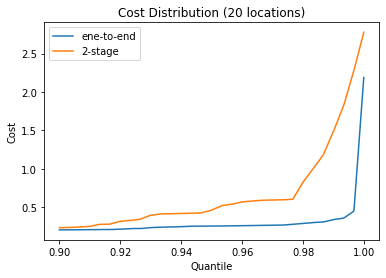

In [62]:
qs = np.arange(0.9,1,0.0001)
a = [np.quantile(all_costs, q) for q in qs]
b = [np.quantile(all_costs_2, q) for q in qs]

plt.plot(qs, a, label = 'ene-to-end')
plt.plot(qs, b, label = '2-stage')
plt.legend()
plt.xlabel("Quantile")
plt.ylabel("Cost")
plt.title("Cost Distribution (20 locations)")
    

Text(0.5, 1.0, 'Cost Distribution (5 locations)')

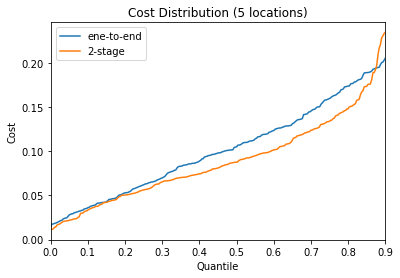

In [63]:
qs = np.arange(0.,0.9,0.0001)
a = [np.quantile(all_costs, q) for q in qs]
b = [np.quantile(all_costs_2, q) for q in qs]

plt.plot(qs, a, label = 'ene-to-end')
plt.plot(qs, b, label = '2-stage')
plt.legend()
plt.xlabel("Quantile")
plt.ylabel("Cost")
plt.xlim(0,0.9)
plt.title("Cost Distribution (5 locations)")
    

In [95]:
q = 1
print(np.quantile(all_costs, q) * n_nodes)
print(np.quantile(all_costs_2, q) * n_nodes)


131.62048387938438
173.2832824664843


In [96]:
print(np.mean(all_costs) * n_nodes)
print(np.mean(all_costs_2) * n_nodes)

2.936460903993532
2.9628777116587153
